Импорт необходимых библиотек

In [2]:
pip install psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 39.9 MB/s eta 0:00:00


In [4]:

import pandas as pd   #Must have :)
import duckdb         #Для обработки запросов SQL внутри без подключения
import psycopg2       #Для работв с внешей БД PostgreSQL
import time           #Для замера времени выполнения
import numpy as np    #Нужен для трансформации данных в заданиях кейса


Загрузка данных в датафремы. Основная идея замерить время на выполнение идентичных действий с помощью:
- Pandas
- PostgreSQL на стороне БД ```psycopg2-binary```
- Имитации MiniSQL ```DuckDB```



1) Подключаемся к внешней БД, выполняем запросы. Формируем датафреймы ```pandas```. Замеряем общее время на реализацию всех 5 заданий

In [5]:
# Так как запросы идентичные, то сразу сохраним их в соответствующие переменные
# Задача 1 Самая ходовая товарная группа
query_task01 = """
SELECT
	coalesce (p.level1,'!!! Категория отсутствует') AS category,
	sum(o.quantity) AS total_sale,
	count (DISTINCT o.order_id) AS cnt_orders
FROM sam_orders o LEFT JOIN sam_products p ON o.product_id =p.product_id
GROUP BY p.level1
ORDER BY total_sale  DESC
"""

# Задача 2 Распределение продаж по подкатегориям
query_task02 = """
WITH marked_category AS (
	SELECT
		p.level1,
		sum(o.quantity) AS total_sale
	FROM sam_orders o JOIN sam_products p ON o.product_id =p.product_id
	GROUP BY p.level1
)
SELECT
	p.level1,
	p.level2,
	sum(o.quantity) AS total_sale
FROM sam_orders o JOIN sam_products p ON o.product_id =p.product_id
JOIN marked_category mc ON mc.level1 = p.level1
GROUP BY p.level1, p.level2, mc.total_sale
ORDER BY mc.total_sale DESC,  total_sale DESC
"""

# Задача 3 Найти средний чек в заданную дату
query_task03 = """
SELECT round(sum(price * quantity) / count(DISTINCT order_id),2) avg_chek
FROM sam_orders
WHERE accepted_at::date = '2022-01-13'
"""

# Задача 4 Доля промо в заданной категории
query_task04 = """
SELECT
	sum(CASE WHEN o.price = o.regular_price  THEN o.quantity END) AS normal,
	sum(CASE WHEN o.price != o.regular_price THEN o.quantity END) AS promo
FROM sam_orders o
JOIN sam_products p ON o.product_id =p.product_id
WHERE p.level1 = 'Сыры'
"""

# Задача 5 Посчитать маржу по категориям
query_task05 = """
SELECT
	level1 AS category,
	sum((price-cost_price)*quantity) AS margin_abs,
	round(sum((price-cost_price)*quantity)*100.0 / sum(price*quantity),2)  AS margin_pct
FROM sam_orders o
JOIN sam_products p ON o.product_id =p.product_id
GROUP BY level1
ORDER BY margin_abs desc
"""

# Задача 6 ABC
query_task06 = """
WITH sales AS (
	SELECT
		level2,
		sum(quantity) AS sum_quantity,
		sum(price*quantity) AS amount
	FROM sam_orders o JOIN sam_products p ON o.product_id =p.product_id
	GROUP BY level2
	ORDER BY sum_quantity desc
),
abs_quant AS (
	SELECT
		level2 AS sub_category,
		CASE
			WHEN sum(sum_quantity) over(ORDER BY sum_quantity desc)/ sum(sum_quantity) over() <0.85
			THEN 'A'
			WHEN sum(sum_quantity) over(ORDER BY sum_quantity desc)/ sum(sum_quantity) over() <0.95
			THEN 'B'
			ELSE 'C'
		END AS abc_quantity
	FROM sales
	ORDER BY  abc_quantity
),
abs_sum AS (
	SELECT
		level2 AS sub_category,
		CASE
			WHEN sum(amount) over(ORDER BY amount desc)/ sum(amount) over() <0.85
			THEN 'A'
			WHEN sum(amount) over(ORDER BY amount desc)/ sum(amount) over() <0.95
			THEN 'B'
			ELSE 'C'
		END AS abc_summa
	FROM sales
	ORDER BY  abc_summa
)
SELECT
 abs_quant.sub_category,
 ABC_quantity,
 ABC_summa
FROM abs_quant JOIN abs_sum ON abs_quant.sub_category = abs_sum.sub_category
ORDER BY abc_quantity,  abc_summa
"""

In [6]:
# Конфигругация подключения к базе данных с уже загруженными таблицами
config = {
    'host':'109.248.201.217',
    'database':'homework',
    'port':'5432',
    'user':'user_bbi',
    'password':'bbi_forever'
}
start = time.perf_counter()                   #Включаем таймер
try:                                          #Отработаем возможные ошибки
  connection = psycopg2.connect(**config)     #Подключение к БД

  #Для визуализации результаты "лежат каждый в своем датафрейме"
  df_DB_task01 = pd.read_sql_query(query_task01, connection)
  df_DB_task02 = pd.read_sql_query(query_task02, connection)
  df_DB_task03 = pd.read_sql_query(query_task03, connection)
  df_DB_task04 = pd.read_sql_query(query_task04, connection)
  df_DB_task05 = pd.read_sql_query(query_task05, connection)
  df_DB_task06 = pd.read_sql_query(query_task06, connection)

except psycopg2.Error as e:
  print(f"Ошибка при работе с БД: {e}")

finally:
  #Зарываем
  if connection:
     connection.close()
  stop = time.perf_counter()                  #Выключаем таймер
  DB_time = stop-start

  print(f"Время выполнения при работе с внешней БД: {stop - start:.4f} секунд")

/tmp/ipykernel_52739/1233796529.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_DB_task01 = pd.read_sql_query(query_task01, connection)
/tmp/ipykernel_52739/1233796529.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_DB_task02 = pd.read_sql_query(query_task02, connection)
/tmp/ipykernel_52739/1233796529.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_DB_task03 = pd.read_sql_query(query_task03, connection)
/tmp/ipykernel_52739/1233796529.py:17: UserWarning: pandas only supports SQLAlchemy connectable (

Время выполнения при работе с внешней БД: 2.5480 секунд


In [7]:
start = time.perf_counter()                   #Включаем таймер

# Создаем подключение к Excel
conn = duckdb.connect()
conn.execute("INSTALL excel;")
conn.execute("LOAD excel;")

# создаем таблицу sam_product, типы данных создаем самостоятельно
conn.execute("""
CREATE TABLE IF NOT EXISTS sam_products (
  product_id   INT,
  level1       VARCHAR,
  level2       VARCHAR,
  name         VARCHAR
)
""")
#Импортируем данные из файла products.xlsx в таблицу
conn.execute("""
    INSERT INTO sam_products
    SELECT * FROM read_xlsx('products.xlsx', header = true)
""")

#Тоже самое для второй таблицы
conn.execute("""
CREATE TABLE sam_orders (
	order_id		int,
	accepted_at		timestamp,
	product_id		int,
	quantity		  NUMERIC,
	regular_price NUMERIC,
	price			    NUMERIC,
	cost_price 		NUMERIC
)
""")

conn.execute("""
    INSERT INTO sam_orders
    SELECT * FROM read_xlsx('orders.xlsx', header = true)
""")
stop = time.perf_counter()                  #Выключаем таймер
DuckDB_time = stop-start
print(f"Время создания и импорта таблиц  DuckDB: {stop - start:.4f} секунд")

Время создания и импорта таблиц  DuckDB: 0.9137 секунд


 выполняем запросы в ```DuckDB``` сохраняем сразу в датафреймы пандас

In [8]:
start = time.perf_counter()
# Запросы
df_Duck_task01 = conn.execute(query_task01).df()
df_Duck_task02 = conn.execute(query_task02).df()
df_Duck_task03 = conn.execute(query_task03).df()
df_Duck_task04 = conn.execute(query_task04).df()
df_Duck_task05 = conn.execute(query_task05).df()
df_Duck_task06 = conn.execute(query_task06).df()

#Закрываем соединение
conn.close()

stop = time.perf_counter()                  #Выключаем таймер
DuckDB_time2 = stop-start
print(f"Время выполнения при работе с DuckDB: {stop - start:.4f} секунд")


Время выполнения при работе с DuckDB: 0.0925 секунд


In [60]:
# Сравнение результатов
diff1 = df_Duck_task01.compare(df_DB_task01)
diff2 = df_Duck_task02.compare(df_DB_task02)
diff3 = df_Duck_task03.compare(df_DB_task03)
diff4 = df_Duck_task04.compare(df_DB_task04)
diff5 = df_Duck_task05.compare(df_DB_task05)
diff6 = df_Duck_task06.compare(df_DB_task06)

#Прошло успешно

Теперь делаем все в чистом Питоне
*хотя по мне так через SQL понятнее, но посотрим на время выполнения, может тут вся **магия***

In [9]:
start = time.perf_counter()                   #Включаем таймер

orders = pd.read_excel('orders.xlsx')         #Импорт данных
products = pd.read_excel('products.xlsx')

# Задача 1

# Соединяем таблицы заказов и товаров по product_id (левое соединение, чтобы сохранить все заказы,
# даже если по ним нет информации о товаре)
merged = orders.merge(products, on='product_id', how='left')

# Создаём новый столбец 'category': берём level1 и заменяем пропуски (NaN) на строку
# '!!! Категория отсутствует' (аналог COALESCE в SQL)
merged['category'] = merged['level1'].fillna('!!! Категория отсутствует')

# Группируем данные по созданной категории — все строки с одинаковой категорией попадают в одну группу
grouped = merged.groupby('category')

# В каждой группе суммируем количество проданных товаров (quantity) — получаем общие продажи в штуках по категории
total_sale = grouped['quantity'].sum()

# В каждой группе считаем количество уникальных заказов (order_id) — получаем число заказов, включающих товары этой категории
cnt_orders = grouped['order_id'].nunique()

# Собираем результаты в DataFrame: колонка 'total_sale' из Series total_sale, колонка 'cnt_orders' из Series cnt_orders
# reset_index() превращает категорию из индекса обратно в обычный столбец
df_Python_task01 = pd.DataFrame({'total_sale': total_sale, 'cnt_orders': cnt_orders}).reset_index()

# Сортируем строки по убыванию total_sale (категории с наибольшими продажами вверху)
df_Python_task01 = df_Python_task01.sort_values('total_sale', ascending=False)

# Задача 2
merged = orders.merge(products, on='product_id', how='inner')
merged['total_sale_level1'] = merged.groupby('level1')['quantity'].transform('sum')
grouped = merged.groupby(['level1', 'level2', 'total_sale_level1'])
df_Python_task02 = grouped['quantity'].sum().reset_index()
df_Python_task02 = df_Python_task02.rename(columns={'quantity': 'total_sale'})
df_Python_task02 = df_Python_task02.sort_values(['total_sale_level1', 'total_sale'], ascending=[False, False])
df_Python_task02 = df_Python_task02[['level1', 'level2', 'total_sale']]

# Задача 3
filtered = orders[orders['accepted_at'].dt.date == pd.Timestamp('2022-01-13').date()]
avg_chek = round((filtered['price'] * filtered['quantity']).sum() / filtered['order_id'].nunique(), 2)
df_Python_task03 = pd.DataFrame({'avg_chek': [avg_chek]})

# Задача 4
merged = orders.merge(products, on='product_id', how='inner')
cheese = merged[merged['level1'] == 'Сыры']
normal = cheese[cheese['price'] == cheese['regular_price']]['quantity'].sum()
promo = cheese[cheese['price'] != cheese['regular_price']]['quantity'].sum()
df_Python_task04 = pd.DataFrame({'normal': [normal], 'promo': [promo]})

# Задача 5
merged = orders.merge(products, on='product_id', how='inner')
merged['margin_row'] = (merged['price'] - merged['cost_price']) * merged['quantity']
merged['revenue_row'] = merged['price'] * merged['quantity']
grouped = merged.groupby('level1')
margin_abs = grouped['margin_row'].sum()
revenue = grouped['revenue_row'].sum()

# Расчёт процентов с округлением (работает с Series)
margin_pct = (margin_abs / revenue * 100).round(2)

df_Python_task05 = pd.DataFrame({
    'category': margin_abs.index,
    'margin_abs': margin_abs.values,
    'margin_pct': margin_pct.values
})
df_Python_task05 = df_Python_task05.sort_values('margin_abs', ascending=False).reset_index(drop=True)

# Задача 6
# Соединяем заказы с товарами и сразу считаем сумму продаж в деньгах
sales = orders.merge(products, on='product_id', how='inner')
sales['amount'] = sales['price'] * sales['quantity']

# Группируем по подкатегории (level2) и агрегируем
sales = sales.groupby('level2').agg(
    sum_quantity=('quantity', 'sum'),
    amount=('amount', 'sum')
).reset_index()

# 1. ABC по количеству
sales_quant = sales[['level2', 'sum_quantity']].copy()
sales_quant = sales_quant.sort_values('sum_quantity', ascending=False)
sales_quant['cumsum'] = sales_quant['sum_quantity'].cumsum()
sales_quant['total'] = sales_quant['sum_quantity'].sum()
sales_quant['cumsum_pct'] = sales_quant['cumsum'] / sales_quant['total']
sales_quant['abc_quantity'] = 'C'
sales_quant.loc[sales_quant['cumsum_pct'] < 0.85, 'abc_quantity'] = 'A'
sales_quant.loc[(sales_quant['cumsum_pct'] >= 0.85) & (sales_quant['cumsum_pct'] < 0.95), 'abc_quantity'] = 'B'

# 2. ABC по сумме
sales_sum = sales[['level2', 'amount']].copy()
sales_sum = sales_sum.sort_values('amount', ascending=False)
sales_sum['cumsum'] = sales_sum['amount'].cumsum()
sales_sum['total'] = sales_sum['amount'].sum()
sales_sum['cumsum_pct'] = sales_sum['cumsum'] / sales_sum['total']
sales_sum['abc_summa'] = 'C'
sales_sum.loc[sales_sum['cumsum_pct'] < 0.85, 'abc_summa'] = 'A'
sales_sum.loc[(sales_sum['cumsum_pct'] >= 0.85) & (sales_sum['cumsum_pct'] < 0.95), 'abc_summa'] = 'B'

# 3. Объединение и итоговая группа
df_Python_task06 = sales_quant[['level2', 'abc_quantity']].merge(
    sales_sum[['level2', 'abc_summa']], on='level2', how='inner'
)
df_Python_task06['ABC_group'] = df_Python_task06['abc_quantity'] + ' ' + df_Python_task06['abc_summa'] #Добавлена специально для визуализации

stop = time.perf_counter()                  #Выключаем таймер
Python_time2 = stop-start
print(f"Время выполнения при работе с Pandas only: {stop - start:.4f} секунд")


Время выполнения при работе с Pandas only: 2.4105 секунд


Сравним результаты pandas и DuckDB

In [85]:
# Сравнение результатов
# Task 01
set_duck_01 = set(df_Duck_task01[['category', 'total_sale', 'cnt_orders']].itertuples(index=False))
set_python_01 = set(df_Python_task01[['category', 'total_sale', 'cnt_orders']].itertuples(index=False))
print("Task 01:", set_duck_01 == set_python_01)

# Task 02 (ключи: level1, level2, total_sale)
set_duck_02 = set(df_Duck_task02[['level1', 'level2', 'total_sale']].itertuples(index=False))
set_python_02 = set(df_Python_task02[['level1', 'level2', 'total_sale']].itertuples(index=False))
print("Task 02:", set_duck_02 == set_python_02)

# Task 03 (единственное значение – сравниваем напрямую)
# Можно взять скаляр
duck_val_03 = df_Duck_task03.loc[0, 'avg_chek'] if not df_Duck_task03.empty else None
python_val_03 = df_Python_task03.loc[0, 'avg_chek'] if not df_Python_task03.empty else None
print("Task 03:", duck_val_03 == python_val_03)

# Task 04 (одна строка с normal, promo)
set_duck_04 = set(df_Duck_task04[['normal', 'promo']].itertuples(index=False))
set_python_04 = set(df_Python_task04[['normal', 'promo']].itertuples(index=False))
print("Task 04:", set_duck_04 == set_python_04)

# Task 05 (category, margin_abs, margin_pct)
set_duck_05 = set(df_Duck_task05[['category', 'margin_abs', 'margin_pct']].itertuples(index=False))
set_python_05 = set(df_Python_task05[['category', 'margin_abs', 'margin_pct']].itertuples(index=False))
print("Task 05:", set_duck_05 == set_python_05)

#Сравнение прошло успешно ABC не сравнивался, т.к. там +1 колонка

Task 01: True
Task 02: True
Task 03: True
Task 04: True
Task 05: True


Переходим к визуализации. Можно использовать любой набор датафреймов, так как они идентичные

In [10]:
# Да будет Сиабон )
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import textwrap


Задача 1

In [11]:
#Зададим единую цветовую гамму
#Вариант 1
'''
# Цветовая палитра для графика 1
base_color1 = '#5B7B9A'      # серо-синий (основной)
top_color1 = '#D97A3E'       # терракотовый (лидеры – тепло, но мягко)
outsider_color1 = '#B0C4CE'  # холодный серо-голубой (аутсайдеры)

# Цветовая палитра для графика 1
base_color2 = '#6B8E6B'      # серо-зелёный (основной)
top_color2 = '#C97E5A'       # приглушённый оранжево-розовый
outsider_color2 = '#C5D0C5'  # светлый серо-зелёный

# Общие цвета
back_color = '#F4F6F9'       # очень светлый серо-синий
text_color = '#2C3E4E'       # тёмный графит
'''
#Вариант 2
'''
base_color1 = '#6C7A89'      # серо-индиго
top_color1 = '#C47A5A'       # терракотовый (мягкий)
outsider_color1 = '#A9B2BC'  # холодный светлый серый

base_color2 = '#4F5E6B'      # глубокий серо-синий
top_color2 = '#A86F54'       # более тёмная терракота
outsider_color2 = '#8E9BA8'  # средний серо-синий

back_color = '#F0F2F5'       # классический светлый фон
text_color = '#2A333D'       # почти чёрный с синим подтоном
'''

#Вариант 3

base_color2 = '#6C8D8C'      # приглушённый аквамарин
top_color2 = '#D6B575'       # сухой песок / шампань
outsider_color2 = '#B8C9C8'  # светлый серо-аквамарин

base_color1 = '#4A6F6E'      # тёмный аквамарин
top_color1 = '#CAA86A'       # более насыщенный песочный
outsider_color1 = '#A1B7B6'  # средний серо-аквамарин

back_color = '#EDF2F2'       # очень светлый холодный серый
text_color = '#2C3A3A'       # тёмный серо-зелёный


#Вариант 4
'''
base_color1 = '#8A929B'      # холодный серый (основной)
top_color1 = '#C59A6B'       # охра/золотистый
outsider_color1 = '#BFC5CC'  # светло-серый

base_color2 = '#6E7B85'      # серо-сизый
top_color2 = '#AD8862'       # тёмная охра
outsider_color2 = '#AEB6BD'  # серо-голубоватый

back_color = '#F3F4F6'       # почти белый
text_color = '#2B3238'       # тёмный грифель
'''

#Вариант 5
'''
base_color1 = '#7B9E7B'      # мягкий шалфей
top_color1 = '#CF9F5E'       # янтарно-песочный (единственный цветовой переход)
outsider_color1 = '#B8CEB8'  # светлая мята

base_color2 = '#5A7A5A'      # тёмный шалфей
top_color2 = '#C28D4A'       # тёплый янтарь
outsider_color2 = '#9BBF9B'  # средняя мята

back_color = '#F5F7F2'       # белый с каплей зелёного
text_color = '#2C3A2A'       # тёмный хвойный
'''

"\nbase_color1 = '#7B9E7B'      # мягкий шалфей\ntop_color1 = '#CF9F5E'       # янтарно-песочный (единственный цветовой переход)\noutsider_color1 = '#B8CEB8'  # светлая мята\n\nbase_color2 = '#5A7A5A'      # тёмный шалфей\ntop_color2 = '#C28D4A'       # тёплый янтарь\noutsider_color2 = '#9BBF9B'  # средняя мята\n\nback_color = '#F5F7F2'       # белый с каплей зелёного\ntext_color = '#2C3A2A'       # тёмный хвойный\n"

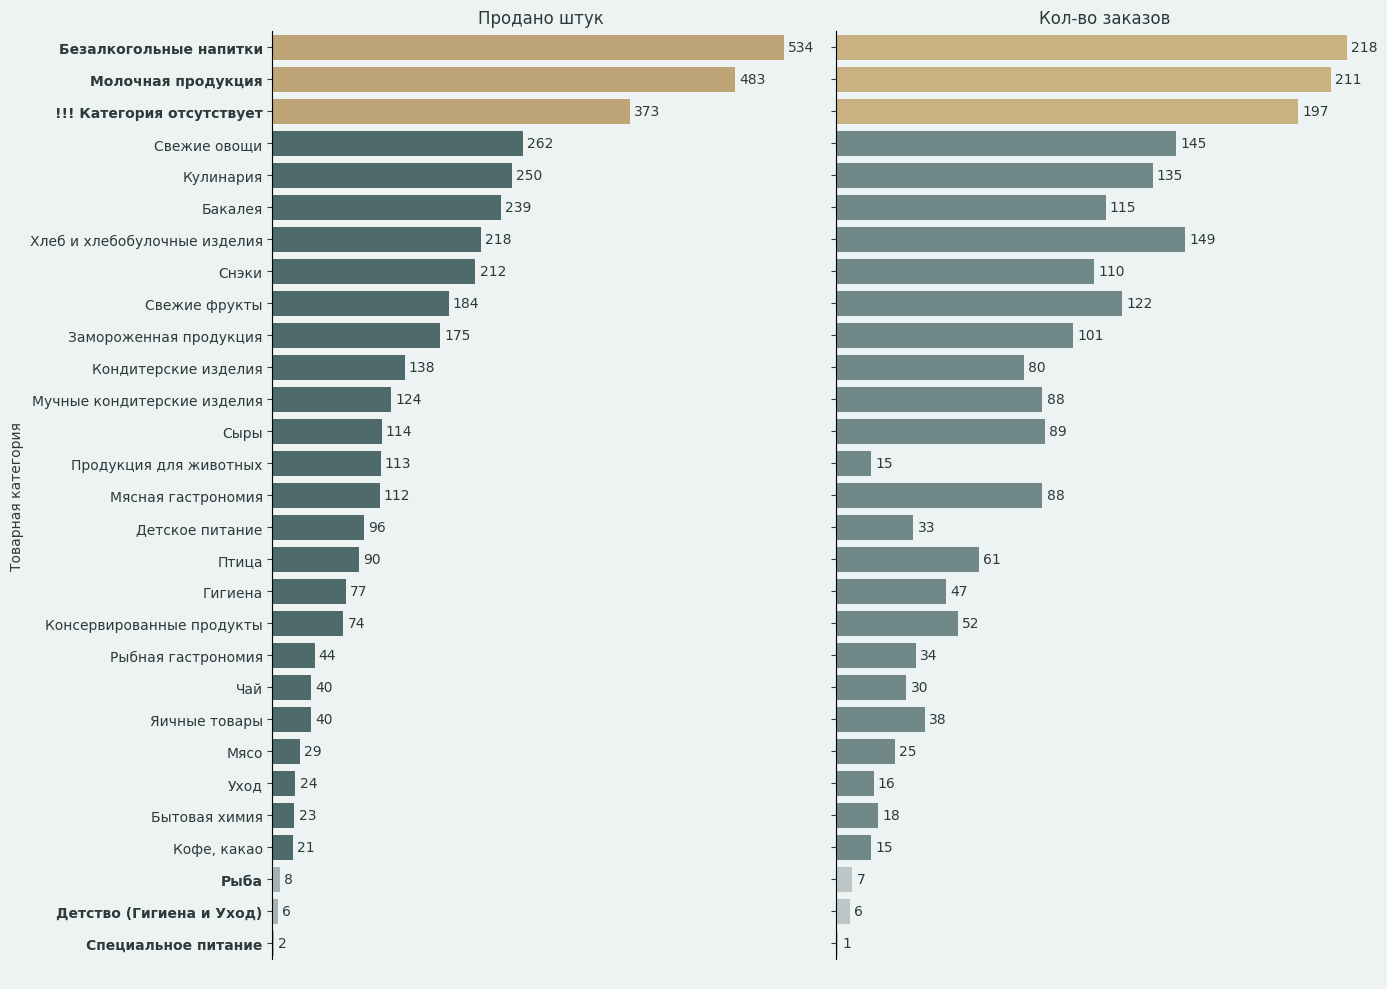

In [54]:
# Данные
n = len(df_Duck_task01)

top_n = 3                              # количество топ-категорий
bottom_n = 3                           # количество категорий-аутсайдеров
n = len(df_Duck_task01)                # общее число категорий

#Задаем цвета для перого графика
colors1 = [base_color1] * n
colors1[:top_n] = [top_color1] * top_n
colors1[-bottom_n:] = [outsider_color1] * bottom_n

#Задаем цвета для второго графика
colors2 = [base_color2] * n
colors2[:top_n] = [top_color2] * top_n
colors2[-bottom_n:] = [outsider_color2] * bottom_n

# Создаём фигуру
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10))
fig.patch.set_facecolor(back_color)   # цвет фона всей фигуры (светло-серый)

# Настройка фона под графиком
ax1.set_facecolor(back_color)
ax2.set_facecolor(back_color)

# Левый график
sns.barplot(data=df_Duck_task01, y='category', x='total_sale', hue='category', palette=colors1, legend=False, ax=ax1)

ax1.set_title('Продано штук', color=text_color)
ax1.set_xlabel(' ')
ax1.set_ylabel('Товарная категория', color=text_color)
#ax1.tick_params(axis='x', colors=text_color) # теперь не нужно
ax1.tick_params(axis='y', colors=text_color)

#убираем ось
ax1.set_xticks([])                         # убираем метки делений
ax1.spines['bottom'].set_visible(False)   # опционально: скрыть линию оси

# Правый график
sns.barplot(data=df_Duck_task01, y='category', x='cnt_orders', hue='category', palette=colors2, legend=False, ax=ax2)

ax2.set_title('Кол-во заказов', color=text_color)
ax2.set_xlabel(' ')
ax2.set_ylabel('')
ax2.set_yticklabels([])
#ax2.tick_params(axis='x', colors=text_color) # теперь не нужно
ax2.tick_params(axis='y', colors=text_color)

#убираем ось
ax2.set_xticks([])                         # убираем метки делений
ax2.spines['bottom'].set_visible(False)   # опционально: скрыть линию оси

# Выделение лидеров и аутсайдеров на левом графике ---
for i, label in enumerate(ax1.get_yticklabels()):
    if i < top_n or i >= n - bottom_n:
        label.set_fontweight('bold')

# Убираем рамки
sns.despine(ax=ax1)
sns.despine(ax=ax1, bottom=True)

sns.despine(ax=ax2)
sns.despine(ax=ax2, bottom=True)

#добавляем подписи
for bars in ax1.containers: #Первый график
    ax1.bar_label(bars, fmt='%.0f', label_type='edge', padding=3, color=text_color)

for bars in ax2.containers: #Второй график
    ax2.bar_label(bars, fmt='%.0f', label_type='edge', padding=3, color=text_color)

plt.tight_layout()
plt.show()

Распределение продаж по подкатегориям
Оцените распределение количества проданных позиций в каждой товарной категории (level1) по подкатегориям (level2). Проиллюстрируйте свой результат расчетной таблицей.

/tmp/ipykernel_579/190963161.py:42: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


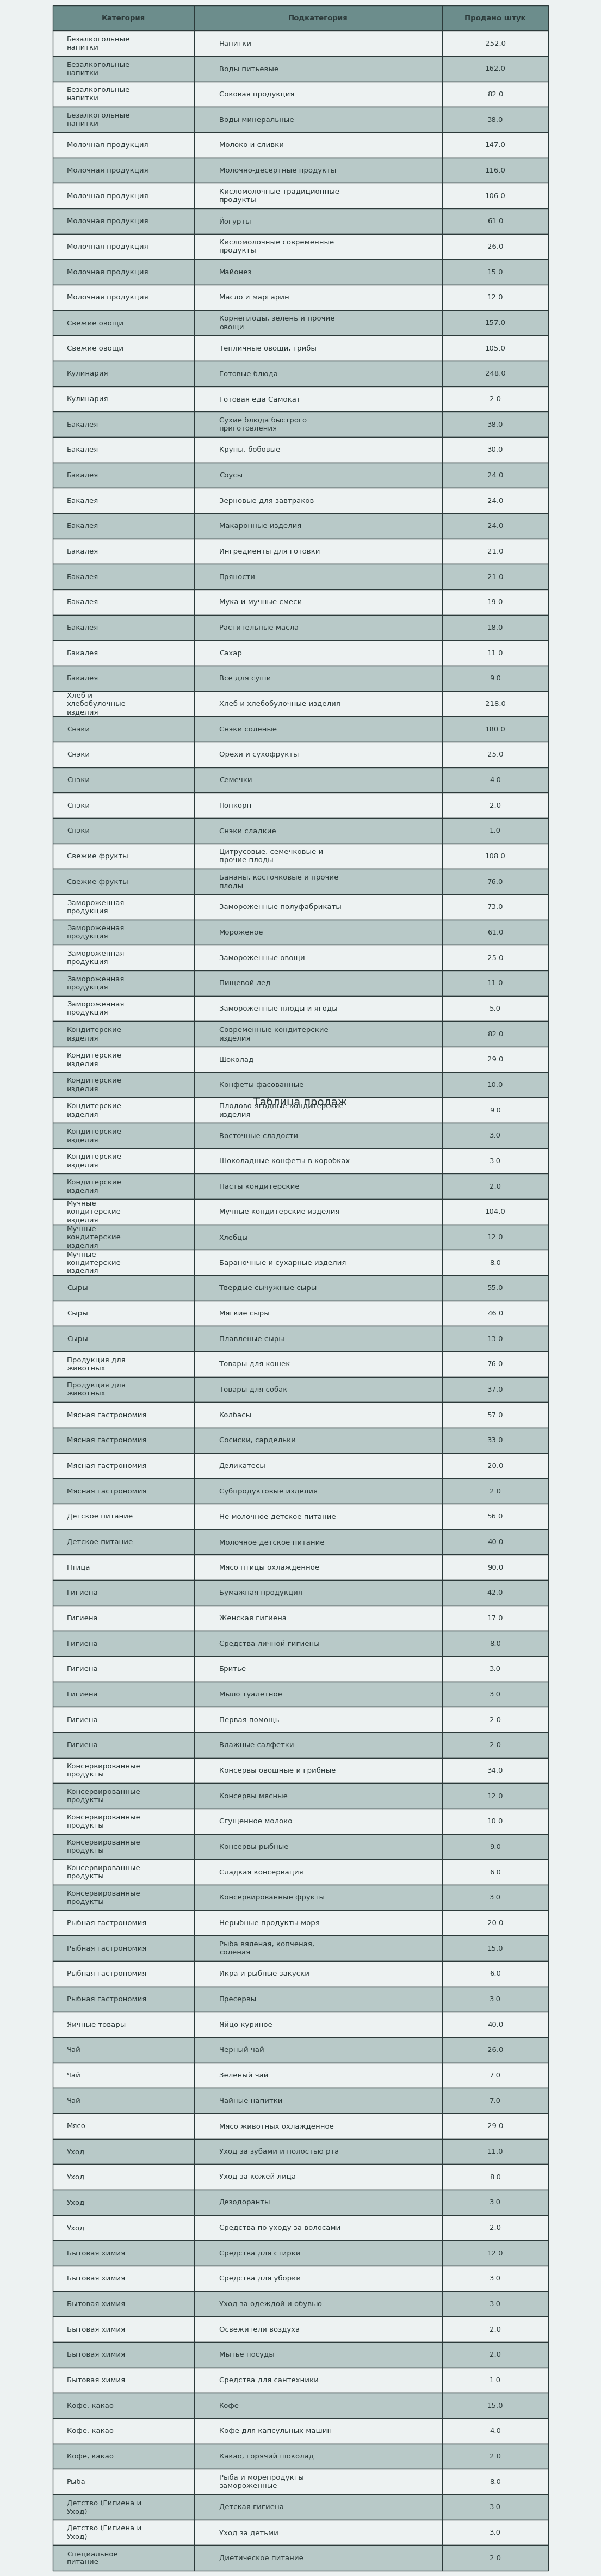

In [65]:
fig, ax = plt.subplots(figsize=(14, 8), facecolor=back_color)
ax.axis('off')

# Перенос текста
def wrap_text(text, width=16):
    return '\n'.join(textwrap.wrap(str(text), width=width))

df_display = df_Duck_task02[['level1', 'level2', 'total_sale']].copy()
df_display['level1'] = df_display['level1'].apply(lambda x: wrap_text(x, width=18))
df_display['level2'] = df_display['level2'].apply(lambda x: wrap_text(x, width=30))

table_data = df_display.values
columns = ['Категория', 'Подкатегория', 'Продано штук']
col_widths = [0.20, 0.35, 0.15]

table = ax.table(cellText=table_data, colLabels=columns,
                 cellLoc='left', loc='center',
                 colWidths=col_widths)

table.auto_set_font_size(False)
table.set_fontsize(9.5)
table.scale(1.2, 2.8)

# Применяем цвета с чередованием строк
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor(base_color2)
        cell.set_text_props(weight='bold', color=text_color)
    else:
        # Чередование: чётные строки (row % 2 == 0) -> outsider_color2
        # Нечётные (row % 2 == 1) -> back_color
        if row % 2 == 0:
            cell.set_facecolor(outsider_color2)
        else:
            cell.set_facecolor(back_color)
        cell.set_text_props(color=text_color)
    cell.set_edgecolor(text_color)
    if col == 2 and row != 0:
        cell.set_text_props(ha='center')

ax.set_title('Таблица продаж', fontsize=14, color=text_color, pad=20)
plt.tight_layout()
plt.show()

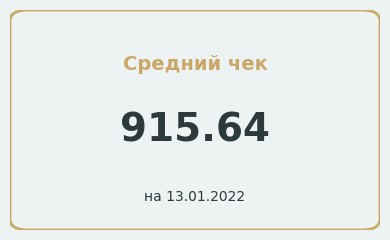

In [79]:
avg_check_value =df_Duck_task03.iloc[0, 0]

fig, ax = plt.subplots(figsize=(4, 2.5), facecolor=back_color)
ax.set_facecolor(back_color)
ax.axis('off')  # убираем оси

# Рисуем прямоугольник (карточку) – можно использовать ax.add_patch
card = patches.FancyBboxPatch((0.05, 0.05), 0.9, 0.9,
                               boxstyle="round,pad=0.05",
                               facecolor=back_color,
                               edgecolor=top_color1,
                               linewidth=2,
                               transform=ax.transAxes)
ax.add_patch(card)

# Заголовок (Средний чек)
ax.text(0.5, 0.75, 'Средний чек',
        transform=ax.transAxes,
        fontsize=14, fontweight='bold',
        color=top_color1, ha='center', va='center')

# Значение (цифра)
ax.text(0.5, 0.45, f'{avg_check_value:,.2f}' if isinstance(avg_check_value, (int, float)) else str(avg_check_value),
        transform=ax.transAxes,
        fontsize=28, fontweight='bold',
        color=text_color, ha='center', va='center')

# Дата внизу
ax.text(0.5, 0.15, 'на 13.01.2022',
        transform=ax.transAxes,
        fontsize=10,
        color=text_color, ha='center', va='center')

plt.tight_layout()
plt.show()

In [88]:
values = df_Duck_task04.iloc[:, 0].values

values

df_Duck_task04

,normal,promo
0,79.0,35.0


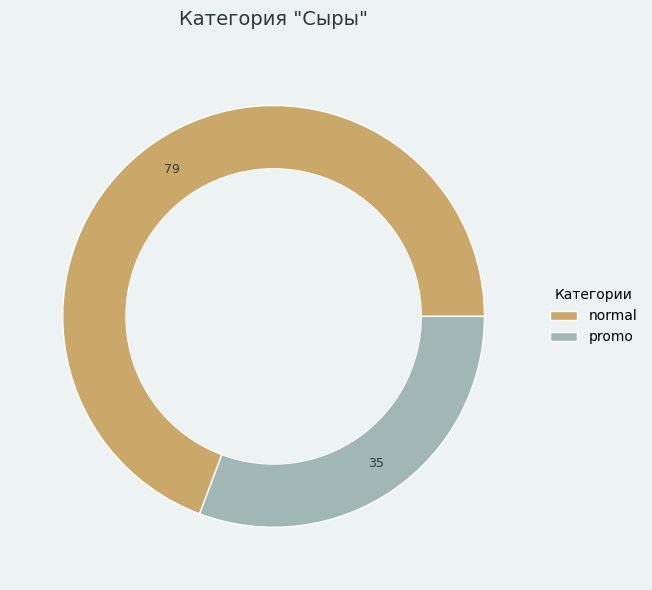

In [92]:
values = df_Duck_task04.iloc[0].values  # получаем массив значений
labels = df_Duck_task04.columns         # заголовки

# Определяем, какое значение больше
if values[0] >= values[1]:
    colors = [top_color1, outsider_color1]   # первый больше -> top, второй меньше -> base
else:
    colors = [outsider_color1, top_color1]   # наоборот

# Функция для отображения абсолютных значений на секторах
def make_autopct(vals):
    def autopct(pct):
        total = sum(vals)
        val = int(round(pct * total / 100.0))
        return f'{val}'
    return autopct

# Построение бублика
fig, ax = plt.subplots(figsize=(7, 6), facecolor=back_color)  # чуть шире для легенды
ax.set_facecolor(back_color)

wedges, texts, autotexts = ax.pie(values,
                                  labels=None,   # не подписываем сектора напрямую
                                  colors=colors,
                                  autopct=make_autopct(values),
                                  pctdistance=0.85,
                                  wedgeprops=dict(width=0.3, edgecolor='white'),
                                  textprops={'color': text_color, 'fontsize': 9})

# Белый круг в центре
centre_circle = plt.Circle((0, 0), 0.70, fc=back_color, edgecolor='none')
ax.add_artist(centre_circle)

ax.legend(wedges, labels, title="Категории", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), frameon=False) #Легенда
ax.set_title('Категория "Сыры"', fontsize=14, color=text_color, pad=20)

plt.tight_layout()
plt.show()

Задача 5
Посчитать маржу по категориям
Визуализация такая же как во втором задании


/tmp/ipykernel_579/4252572439.py:27: UserWarning: The palette list has more values (29) than needed (28), which may not be intended.
  sns.barplot(data=df_Duck_task05, y='category', x='margin_abs', hue='category', palette=colors1, legend=False, ax=ax1)
/tmp/ipykernel_579/4252572439.py:40: UserWarning: The palette list has more values (29) than needed (28), which may not be intended.
  sns.barplot(data=df_Duck_task05, y='category', x='margin_pct', hue='category', palette=colors2, legend=False, ax=ax2)


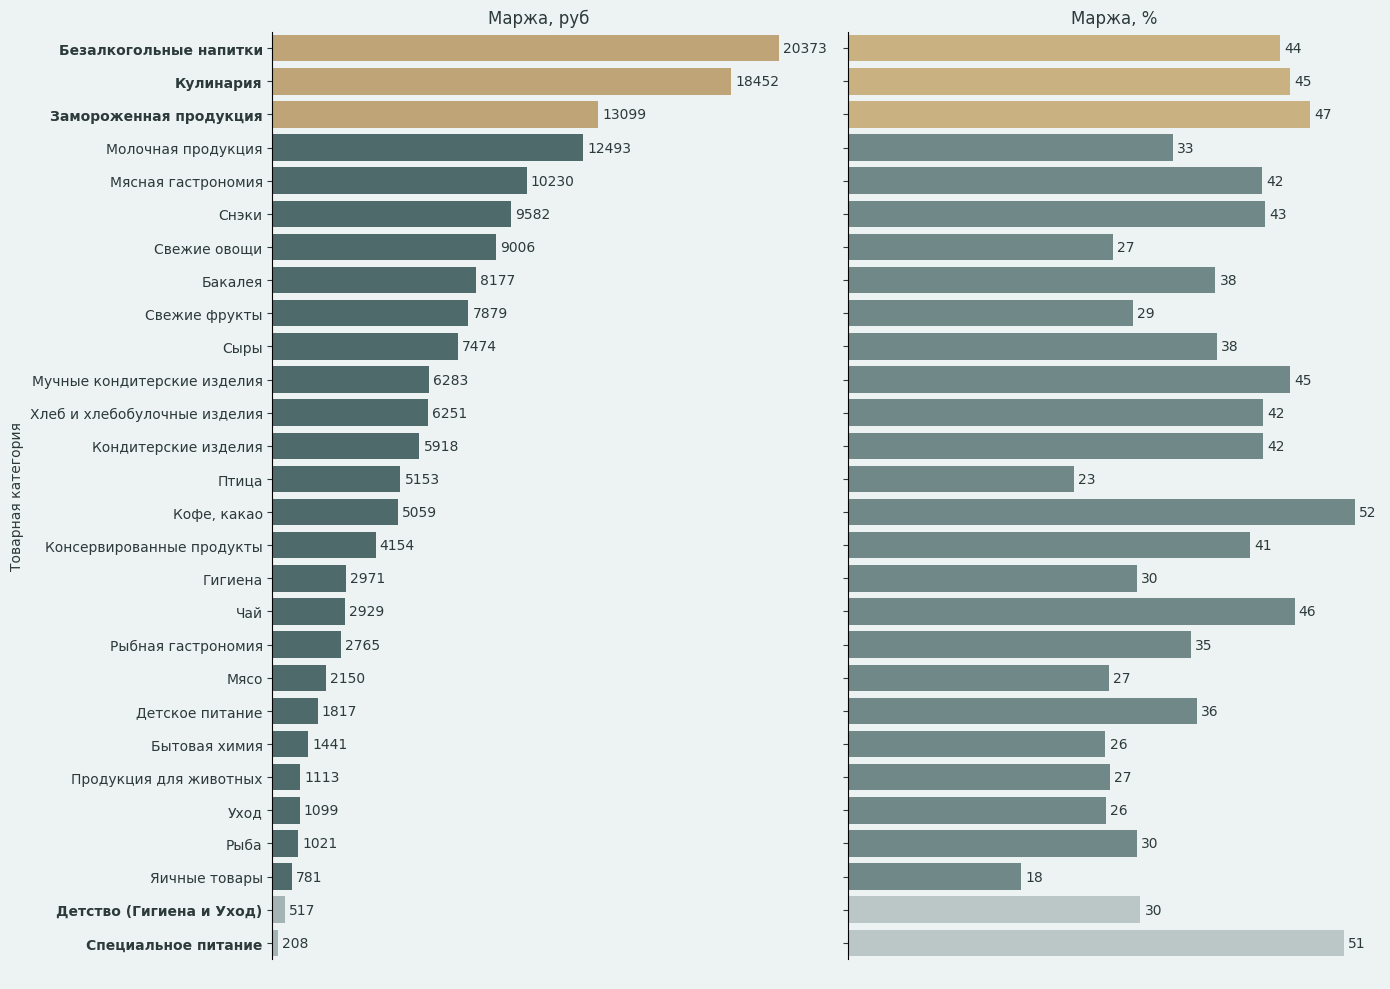

In [98]:
# Данные
n = len(df_Duck_task05)

top_n = 3                              # количество топ-категорий
bottom_n = 3                           # количество категорий-аутсайдеров
n = len(df_Duck_task01)                # общее число категорий

#Задаем цвета для перого графика
colors1 = [base_color1] * n
colors1[:top_n] = [top_color1] * top_n
colors1[-bottom_n:] = [outsider_color1] * bottom_n

#Задаем цвета для второго графика
colors2 = [base_color2] * n
colors2[:top_n] = [top_color2] * top_n
colors2[-bottom_n:] = [outsider_color2] * bottom_n

# Создаём фигуру
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10))
fig.patch.set_facecolor(back_color)   # цвет фона всей фигуры (светло-серый)

# Настройка фона под графиком
ax1.set_facecolor(back_color)
ax2.set_facecolor(back_color)

# Левый график
sns.barplot(data=df_Duck_task05, y='category', x='margin_abs', hue='category', palette=colors1, legend=False, ax=ax1)

ax1.set_title('Маржа, руб', color=text_color)
ax1.set_xlabel(' ')
ax1.set_ylabel('Товарная категория', color=text_color)
#ax1.tick_params(axis='x', colors=text_color) # теперь не нужно
ax1.tick_params(axis='y', colors=text_color)

#убираем ось
ax1.set_xticks([])                         # убираем метки делений
ax1.spines['bottom'].set_visible(False)   # опционально: скрыть линию оси

# Правый график
sns.barplot(data=df_Duck_task05, y='category', x='margin_pct', hue='category', palette=colors2, legend=False, ax=ax2)

ax2.set_title('Маржа, %', color=text_color)
ax2.set_xlabel(' ')
ax2.set_ylabel('')
ax2.set_yticklabels([])
#ax2.tick_params(axis='x', colors=text_color) # теперь не нужно
ax2.tick_params(axis='y', colors=text_color)

#убираем ось
ax2.set_xticks([])                         # убираем метки делений
ax2.spines['bottom'].set_visible(False)   # опционально: скрыть линию оси

# Выделение лидеров и аутсайдеров на левом графике ---
for i, label in enumerate(ax1.get_yticklabels()):
    if i < top_n or i >= n - bottom_n:
        label.set_fontweight('bold')

# Убираем рамки
sns.despine(ax=ax1)
sns.despine(ax=ax1, bottom=True)

sns.despine(ax=ax2)
sns.despine(ax=ax2, bottom=True)

#добавляем подписи
for bars in ax1.containers: #Первый график
    ax1.bar_label(bars, fmt='%.0f', label_type='edge', padding=3, color=text_color)

for bars in ax2.containers: #Второй график
    ax2.bar_label(bars, fmt='%.0f', label_type='edge', padding=3, color=text_color)

plt.tight_layout()
plt.show()

In [13]:
df_Duck_task05.sort_values('margin_pct', ascending=False)

,category,margin_abs,margin_pct
14,"Кофе, какао",5059.0,51.83
27,Специальное питание,208.0,50.73
2,Замороженная продукция,13099.0,47.26
17,Чай,2929.0,45.67
10,Мучные кондитерские изделия,6283.0,45.19
1,Кулинария,18452.0,45.18
0,Безалкогольные напитки,20373.0,44.19
5,Снэки,9582.0,42.63
12,Кондитерские изделия,5918.0,42.45
11,Хлеб и хлебобулочные изделия,6251.0,42.45


/tmp/ipykernel_52739/23966226.py:27: UserWarning: The palette list has more values (29) than needed (28), which may not be intended.
  sns.barplot(data = df_Duck_task05.sort_values('margin_pct', ascending=False) ,
/tmp/ipykernel_52739/23966226.py:41: UserWarning: The palette list has more values (29) than needed (28), which may not be intended.
  sns.barplot(data=df_Duck_task05.sort_values('margin_pct', ascending=False),


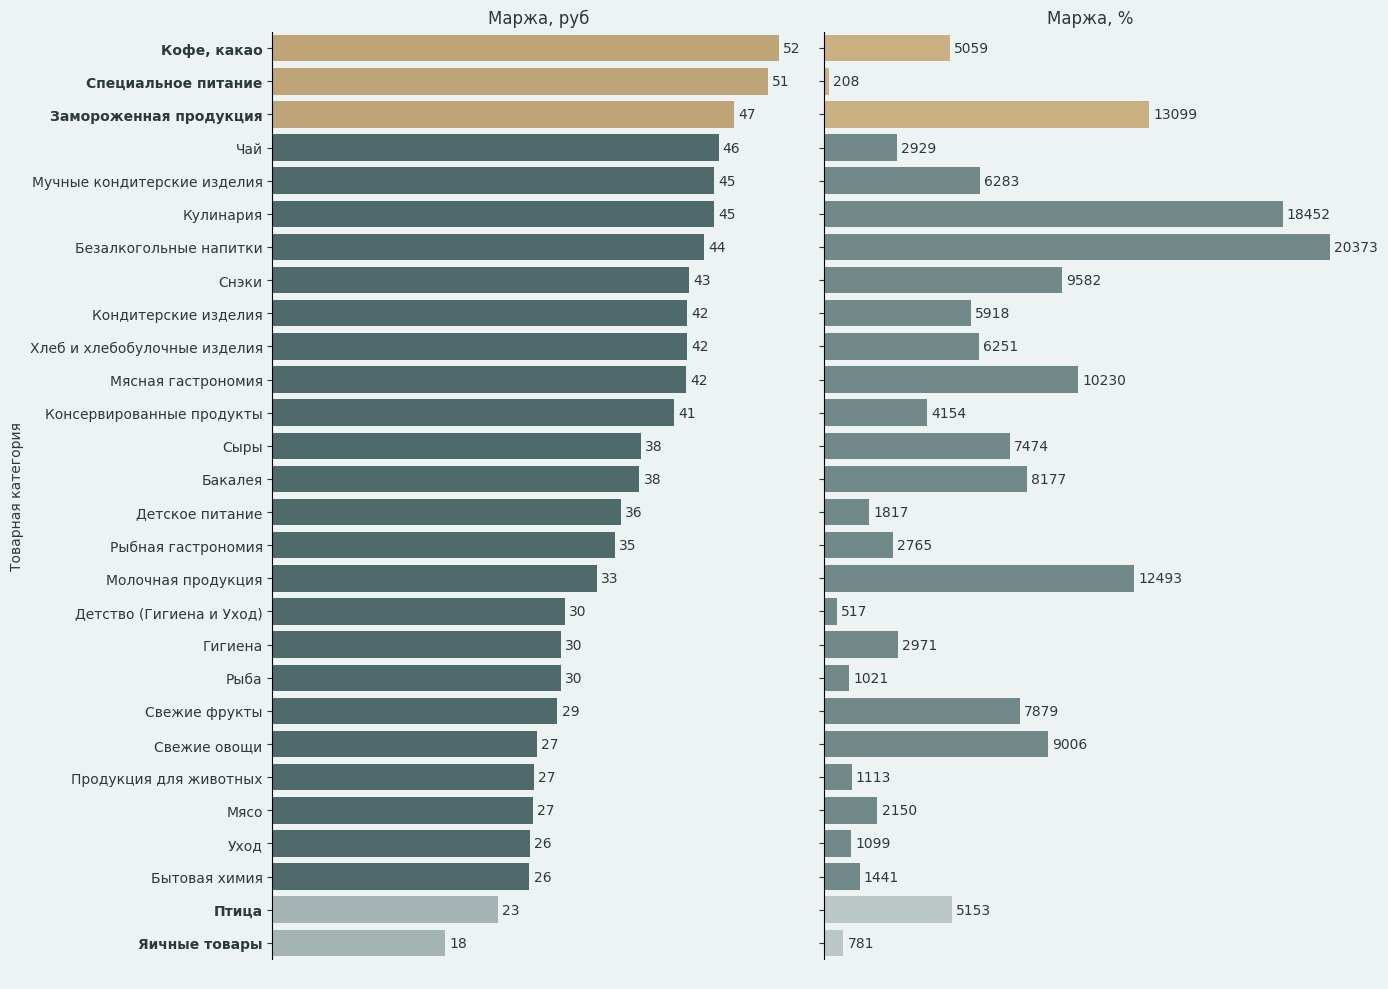

In [14]:
# Данные
n = len(df_Duck_task05)

top_n = 3                              # количество топ-категорий
bottom_n = 3                           # количество категорий-аутсайдеров
n = len(df_Duck_task01)                # общее число категорий

#Задаем цвета для перого графика
colors1 = [base_color1] * n
colors1[:top_n] = [top_color1] * top_n
colors1[-bottom_n:] = [outsider_color1] * bottom_n

#Задаем цвета для второго графика
colors2 = [base_color2] * n
colors2[:top_n] = [top_color2] * top_n
colors2[-bottom_n:] = [outsider_color2] * bottom_n

# Создаём фигуру
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10))
fig.patch.set_facecolor(back_color)   # цвет фона всей фигуры (светло-серый)

# Настройка фона под графиком
ax1.set_facecolor(back_color)
ax2.set_facecolor(back_color)

# Левый график
sns.barplot(data = df_Duck_task05.sort_values('margin_pct', ascending=False) ,
            y='category', x='margin_pct', hue='category', palette=colors1, legend=False, ax=ax1)

ax1.set_title('Маржа, руб', color=text_color)
ax1.set_xlabel(' ')
ax1.set_ylabel('Товарная категория', color=text_color)
#ax1.tick_params(axis='x', colors=text_color) # теперь не нужно
ax1.tick_params(axis='y', colors=text_color)

#убираем ось
ax1.set_xticks([])                         # убираем метки делений
ax1.spines['bottom'].set_visible(False)   # опционально: скрыть линию оси

# Правый график
sns.barplot(data=df_Duck_task05.sort_values('margin_pct', ascending=False),
            y='category', x='margin_abs', hue='category', palette=colors2, legend=False, ax=ax2)

ax2.set_title('Маржа, %', color=text_color)
ax2.set_xlabel(' ')
ax2.set_ylabel('')
ax2.set_yticklabels([])
#ax2.tick_params(axis='x', colors=text_color) # теперь не нужно
ax2.tick_params(axis='y', colors=text_color)

#убираем ось
ax2.set_xticks([])                         # убираем метки делений
ax2.spines['bottom'].set_visible(False)   # опционально: скрыть линию оси

# Выделение лидеров и аутсайдеров на левом графике ---
for i, label in enumerate(ax1.get_yticklabels()):
    if i < top_n or i >= n - bottom_n:
        label.set_fontweight('bold')

# Убираем рамки
sns.despine(ax=ax1)
sns.despine(ax=ax1, bottom=True)

sns.despine(ax=ax2)
sns.despine(ax=ax2, bottom=True)

#добавляем подписи
for bars in ax1.containers: #Первый график
    ax1.bar_label(bars, fmt='%.0f', label_type='edge', padding=3, color=text_color)

for bars in ax2.containers: #Второй график
    ax2.bar_label(bars, fmt='%.0f', label_type='edge', padding=3, color=text_color)

plt.tight_layout()
plt.show()

Таблица ABC

In [101]:
df_Python_task06

,level2,abc_quantity,abc_summa,ABC_group
0,Напитки,A,A,A A
1,Готовые блюда,A,A,A A
2,Хлеб и хлебобулочные изделия,A,A,A A
3,Снэки соленые,A,A,A A
4,Воды питьевые,A,A,A A
...,...,...,...,...
95,Пасты кондитерские,C,C,C C
96,Средства по уходу за волосами,C,C,C C
97,Субпродуктовые изделия,C,C,C C
98,Средства для сантехники,C,C,C C


In [103]:
#Мне не понравилась предыдущая таблица, поэтому воспользуюсь опвтом коллег и адаптирую под себя
table_abc = df_Python_task06  #воспользуемся датафремом pandas т.к. в нем есть объединенный столюбец, а переписывать запрос не хочется

table_abc.columns = ['Подкатегория','ABC (кол-во)', 'ABC (выручка)','Итоговая группа']

# Цвет строки по итоговой группе
def highlight_group(row):
    colors = {
        'A A': 'background-color: #B7E4C7',   # зелёный  — двойной лидер
        'A B': 'background-color: #D8F3DC',
        'B A': 'background-color: #D8F3DC',
        'B B': 'background-color: #FFF3CD',   # жёлтый   — середина
        'A C': 'background-color: #FFE8CC',
        'C A': 'background-color: #FFE8CC',
        'B C': 'background-color: #FADADD',   # розовый  — аутсайдеры
        'C B': 'background-color: #FADADD',
        'C C': 'background-color: #F8B4B4',   # красный  — балласт
    }
    color = colors.get(row['Итоговая группа'], '')
    return [color] * len(row)


styled_abc = (
    table_abc
    .style
    .apply(highlight_group, axis=1)
    .format({
        'Продано штук' : '{:,.0f}',   # если в данных есть такие колонки, но в table_abc их нет? В исходном коде было форматирование, но в table_abc только 4 колонки. Оставим как есть или уберем.
        'Выручка, руб.': '{:,.0f}'
    })
    .set_caption('ABC-анализ')
    .set_table_styles([
        {'selector': 'caption', 'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px 0')]},
        {'selector': 'table', 'props': [('background-color', back_color), ('color', text_color)]},
        {'selector': 'td', 'props': [('color', text_color)]},
        {'selector': 'th', 'props': [('color', text_color)]}
    ])
)

display(styled_abc)

,Подкатегория,ABC (кол-во),ABC (выручка),Итоговая группа
0,Напитки,A,A,A A
1,Готовые блюда,A,A,A A
2,Хлеб и хлебобулочные изделия,A,A,A A
3,Снэки соленые,A,A,A A
4,Воды питьевые,A,A,A A
5,"Корнеплоды, зелень и прочие овощи",A,A,A A
6,Молоко и сливки,A,A,A A
7,Молочно-десертные продукты,A,A,A A
8,"Цитрусовые, семечковые и прочие плоды",A,A,A A
9,Кисломолочные традиционные продукты,A,A,A A
